# Composable Plotting API Showcase

This notebook demonstrates a clean, user-friendly plotting API pattern where:

* Each object has its own `.plot(...)` method
* It **accepts optional axes / figure from the user**
* It **returns** `(fig, axes, artists)` so the caller can further customize

We'll show examples for:
1. Images (single or batch)
2. 1D Spectra (single or batch)
3. Healpy maps (single or batch)
4. Composing multiple plot types in custom layouts

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from dataclasses import dataclass
from collections.abc import Sequence
import healpy as hp

%matplotlib inline

## Helper Functions

These are shared utilities that all plotting classes use:

In [2]:
def _flatten_axes(axes):
    """Return a flat 1D np.array of axes objects."""
    if axes is None:
        return None
    if isinstance(axes, np.ndarray):
        return axes.ravel()
    if isinstance(axes, Sequence):
        return np.array(axes, dtype=object).ravel()
    # Single Axes object
    return np.array([axes], dtype=object)


def _prepare_axes(axes, n_panels, ncols=None, figsize=None):
    """
    Make sure we have at least n_panels axes.
    - If axes is None: create a new fig + axes grid.
    - If axes is provided: flatten it and use the first n_panels.
    
    Returns
    -------
    fig : matplotlib.figure.Figure
    axes_flat : np.ndarray of Axes, length >= n_panels
    """
    if axes is None:
        if ncols is None:
            ncols = min(n_panels, 3)
        nrows = int(np.ceil(n_panels / ncols))
        fig, ax_arr = plt.subplots(
            nrows, ncols, squeeze=False, figsize=figsize
        )
        flat = ax_arr.ravel()
        return fig, flat[:n_panels]

    flat = _flatten_axes(axes)
    if flat.size < n_panels:
        raise ValueError(
            f"Expected at least {n_panels} axes, got {flat.size}."
        )
    fig = flat[0].figure
    return fig, flat[:n_panels]

## 1. ImageSet Class

For plotting 2D images (single or batch):

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from math import ceil
from typing import Optional, Sequence, Tuple
from mpl_toolkits.axes_grid1 import make_axes_locatable


class ImageSet:
    """
    images : array-like, shape (ny, nx) or (n, ny, nx)
    """

    def __init__(self, images):
        arr = np.asarray(images)
        if arr.ndim == 2:
            arr = arr[None, ...]          # (1, ny, nx)
        elif arr.ndim != 3:
            raise ValueError("ImageSet expects (ny, nx) or (n, ny, nx)")
        self.data = arr

    def plot(
        self,
        axes=None,
        *,
        cmap: str = "magma",
        figsize: Optional[Tuple[float, float]] = None,
        ncols: int = 3,
        titles: Optional[Sequence[str]] = None,
        show_colorbar: bool = True,
        show_ticks: bool = True,
        apply_log: bool = False,
        shared_norm: bool = True,
    ):
        """
        Similar behavior to your FlatDensity.plot, but:

        - can reuse user-provided axes (for mixing with other plots)
        - returns (fig, axes)

        Parameters
        ----------
        axes : None or Axes or 2D array-like of Axes
            If None, a new grid of subplots is created.
            If given, must contain at least n_maps axes.
        shared_norm : bool, default=True
            If True, all panels share the same vmin/vmax.
            If False, each panel autoscale independently.
        """
        data = self.data
        n_maps = data.shape[0]

        # --- layout ---
        requested_cols = ncols or 3
        ncols = max(1, min(requested_cols, n_maps))
        nrows = ceil(n_maps / ncols)
        if figsize is None:
            figsize = (5 * ncols, 5 * nrows)

        if axes is None:
            fig, axes_grid = plt.subplots(
                nrows, ncols, figsize=figsize, squeeze=False
            )
        else:
            # Flatten user axes and reshape to (nrows, ncols)
            axes_flat = np.ravel(np.array(axes, dtype=object))
            if axes_flat.size < nrows * ncols:
                raise ValueError(
                    f"Expected at least {nrows * ncols} axes, "
                    f"got {axes_flat.size}"
                )
            fig = axes_flat[0].figure
            axes_grid = axes_flat[: nrows * ncols].reshape(nrows, ncols)

        # --- compute shared norm if requested ---
        if shared_norm:
            if apply_log:
                arr_for_norm = np.log10(data + 1.0)
            else:
                arr_for_norm = data
            vmin = float(np.nanmin(arr_for_norm))
            vmax = float(np.nanmax(arr_for_norm))
        else:
            vmin = vmax = None  # let imshow auto-scale per panel

        # --- plot ---
        ims = []
        axes_list = []

        for idx in range(nrows * ncols):
            ax = axes_grid[idx // ncols, idx % ncols]
            if idx < n_maps:
                arr = data[idx]
                if apply_log:
                    arr = np.log10(arr + 1.0)
                im = ax.imshow(
                    arr,
                    origin="lower",
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                )
                ims.append(im)
                axes_list.append(ax)

                if show_colorbar:
                    divider = make_axes_locatable(ax)
                    cax = divider.append_axes("right", size="3%", pad=0.03)
                    fig.colorbar(im, cax=cax)

                if not show_ticks:
                    ax.set_xticks([])
                    ax.set_yticks([])

                if titles and idx < len(titles):
                    ax.set_title(titles[idx])
            else:
                ax.axis("off")

        fig.tight_layout()
        return fig, np.array(axes_list, dtype=object), ims


### Example 1a: Single Image (Auto Layout)

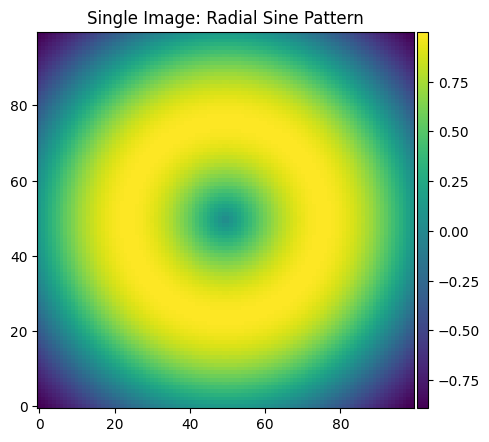

In [4]:
# Create a single image with some structure
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
single_img = np.sin(np.sqrt(X**2 + Y**2))

img_single = ImageSet(single_img)
fig, axes, artists = img_single.plot(cmap="viridis")

# User customization
axes[0].set_title("Single Image: Radial Sine Pattern")
plt.tight_layout()

### Example 1b: Batch of Images (Auto Layout)

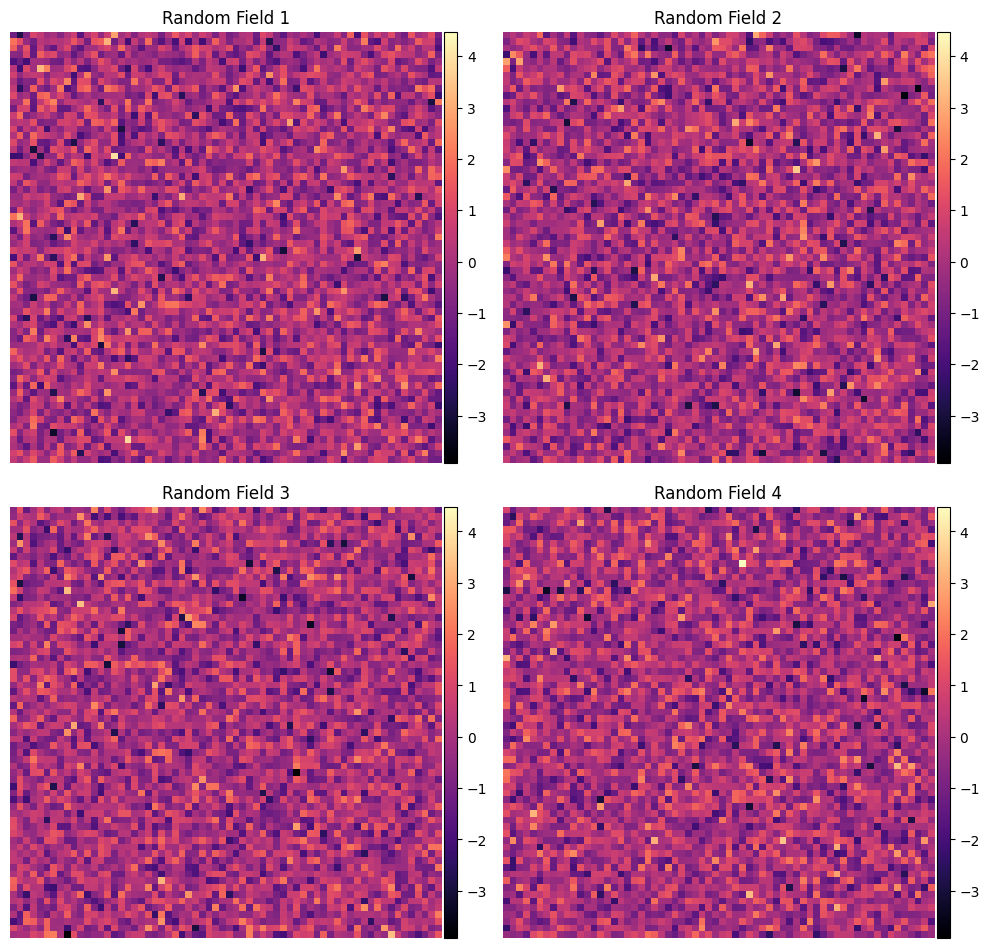

In [5]:
# Create a batch of 4 random images
np.random.seed(42)
batch_imgs = np.random.randn(4, 64, 64)

img_batch = ImageSet(batch_imgs)
fig, axes, artists = img_batch.plot(cmap="magma", ncols=2)

# Add titles to each
for i, ax in enumerate(axes):
    ax.set_title(f"Random Field {i+1}")
    ax.axis('off')
    
plt.tight_layout()

### Example 1c: Using Custom Axes

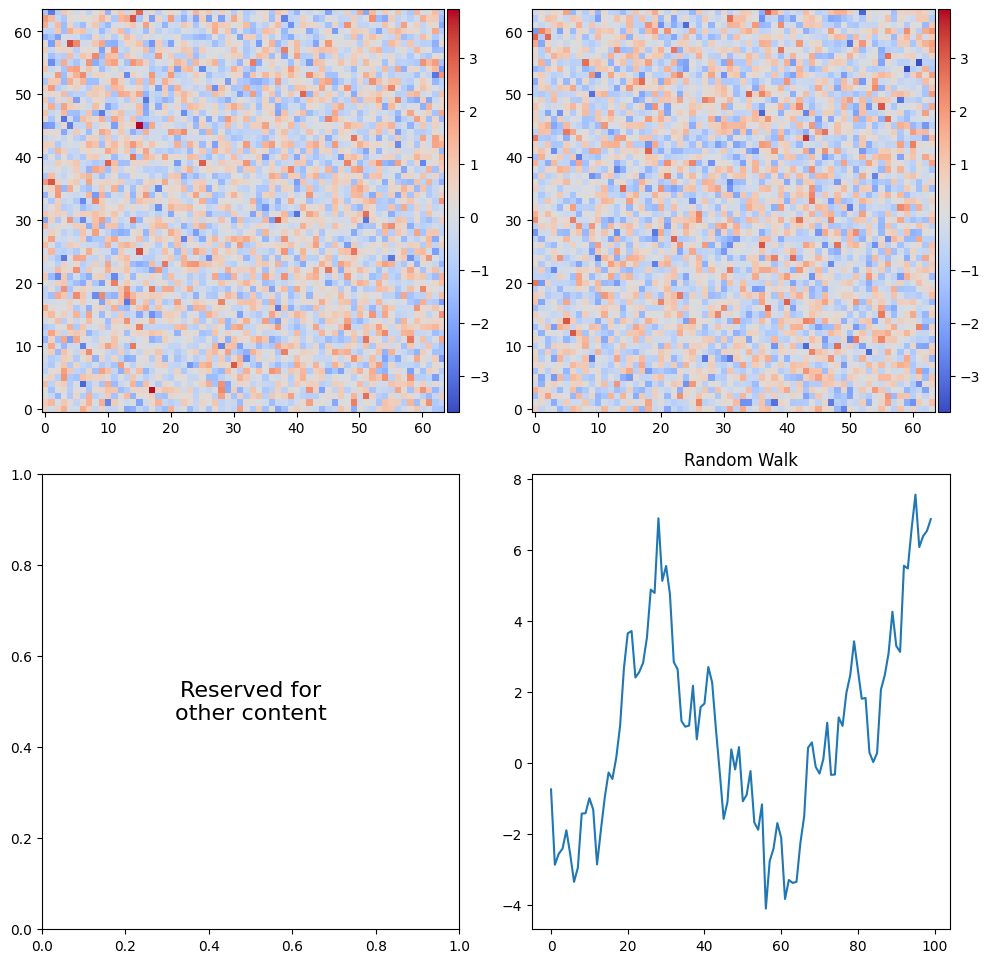

In [6]:
# User creates their own figure and axes
fig, ax_grid = plt.subplots(2, 2, figsize=(10, 10))

# Put 2 images in the top row
imgs_2 = ImageSet(batch_imgs[:2])
fig, axes_used, _ = imgs_2.plot(axes=ax_grid[0, :], cmap="coolwarm")

# User can use the bottom row for something else
ax_grid[1, 0].text(0.5, 0.5, "Reserved for\nother content", 
                   ha='center', va='center', fontsize=16)
ax_grid[1, 1].plot(np.random.randn(100).cumsum())
ax_grid[1, 1].set_title("Random Walk")

plt.tight_layout()

## 2. SpectrumSet Class

For plotting 1D spectra (single or batch):

In [7]:
@dataclass
class SpectrumSet:
    """
    x: np.ndarray of shape (M,)
    y: np.ndarray of shape (M,) or (N, M)
    """
    x: np.ndarray
    y: np.ndarray

    def _as_batch(self):
        x = np.asarray(self.x)
        y = np.asarray(self.y)
        if x.ndim != 1:
            raise ValueError("x must be 1D")
        if y.ndim == 1:
            y = y[None, :]  # (1, M)
        elif y.ndim != 2:
            raise ValueError("y must be 1D or 2D (N, M)")
        if y.shape[1] != x.shape[0]:
            raise ValueError("y.shape[1] must match x.shape[0]")
        return x, y

    def plot(self, axes=None, ncols=None, figsize=None,
             one_panel=False, **plot_kwargs):
        """
        Plot spectra.

        Parameters
        ----------
        axes : None or Axes or array-like of Axes
        one_panel : bool
            If True, all spectra are plotted into a single Axes.
            If False, one Axes per spectrum.
        **plot_kwargs : passed to ax.plot
        """
        x, y = self._as_batch()
        n = y.shape[0]

        if one_panel:
            fig, ax_arr = _prepare_axes(axes, 1, ncols=1, figsize=figsize)
            ax = ax_arr[0]
            line_artists = []
            for yi in y:
                line, = ax.plot(x, yi, **plot_kwargs)
                line_artists.append(line)
            return fig, np.array([ax]), line_artists

        # One panel per spectrum
        fig, axes_flat = _prepare_axes(axes, n, ncols=ncols, figsize=figsize)
        line_artists = []
        for yi, ax in zip(y, axes_flat):
            line, = ax.plot(x, yi, **plot_kwargs)
            line_artists.append(line)
        return fig, axes_flat[:n], line_artists

### Example 2a: Multiple Spectra in One Panel

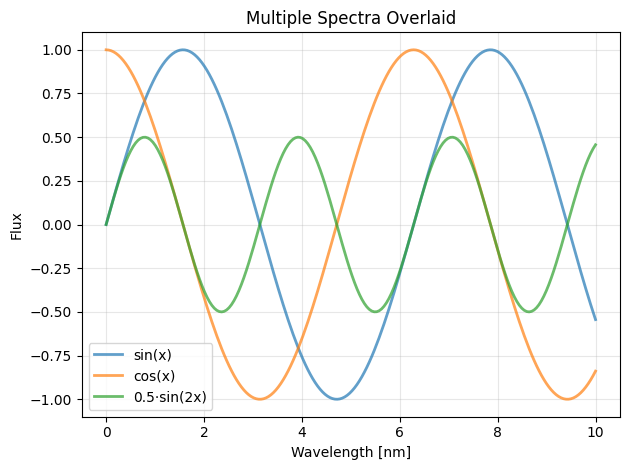

In [8]:
# Create multiple spectra
x = np.linspace(0, 10, 200)
y_multi = np.array([
    np.sin(x),
    np.cos(x),
    np.sin(2*x) * 0.5,
])

specs = SpectrumSet(x, y_multi)
fig, axes, lines = specs.plot(one_panel=True, alpha=0.7, linewidth=2)

# Customize
axes[0].set_xlabel("Wavelength [nm]")
axes[0].set_ylabel("Flux")
axes[0].set_title("Multiple Spectra Overlaid")
axes[0].legend(lines, ["sin(x)", "cos(x)", "0.5·sin(2x)"])
axes[0].grid(True, alpha=0.3)

plt.tight_layout()

### Example 2b: Each Spectrum in Separate Panel

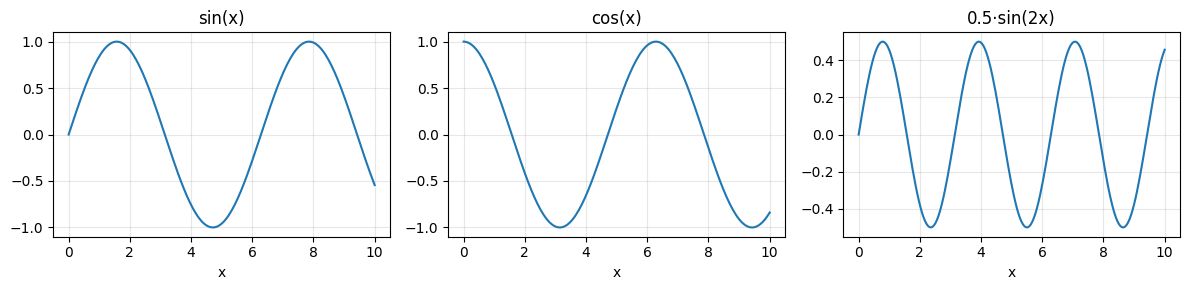

In [9]:
fig, axes, lines = specs.plot(one_panel=False, ncols=3, figsize=(12, 3))

labels = ["sin(x)", "cos(x)", "0.5·sin(2x)"]
for ax, label in zip(axes, labels):
    ax.set_title(label)
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.3)

plt.tight_layout()

### Example 2c: Power Spectrum with Log Scale

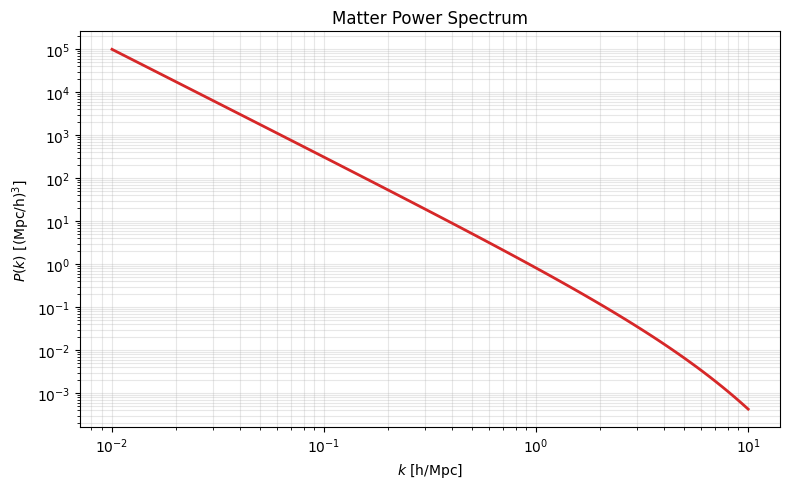

In [10]:
# Simulate a power spectrum
k = np.logspace(-2, 1, 100)
P_k = k**(-2.5) * np.exp(-k/5)  # Power-law with cutoff

power_spec = SpectrumSet(k, P_k)
fig, axes, lines = power_spec.plot(figsize=(8, 5), color='C3', linewidth=2)

axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel(r'$k$ [h/Mpc]')
axes[0].set_ylabel(r'$P(k)$ [(Mpc/h)$^3$]')
axes[0].set_title('Matter Power Spectrum')
axes[0].grid(True, alpha=0.3, which='both')

plt.tight_layout()

## 3. HealpyMapSet Class

For plotting HEALPix maps (single or batch):

In [11]:
@dataclass
class HealpyMapSet:
    """
    maps: np.ndarray of shape (npix,) or (N, npix)
    """
    maps: np.ndarray

    def _as_batch(self):
        maps = np.asarray(self.maps)
        if maps.ndim == 1:
            maps = maps[None, :]
        elif maps.ndim != 2:
            raise ValueError("maps must be 1D or 2D (N, npix)")
        return maps

    def plot(self, fig=None, subplots=None, ncols=3,
             figsize=None, mollview_kwargs=None):
        """
        Plot one or many healpy mollview maps.

        Parameters
        ----------
        fig : matplotlib.figure.Figure or None
            If None, a new figure is created.
        subplots : list of (nrows, ncols, index) or None
            If given, must have at least as many entries as maps.
        ncols : int
            Used when automatically creating subplots.
        mollview_kwargs : dict
            Extra kwargs passed to hp.mollview

        Returns
        -------
        fig : Figure
        axes : list of Axes
        artists : list (dummy, healpy doesn't return artists)
        """
        maps = self._as_batch()
        n = maps.shape[0]
        if mollview_kwargs is None:
            mollview_kwargs = {}

        if fig is None and subplots is None:
            if figsize is None:
                figsize = (4 * min(n, ncols), 3 * int(np.ceil(n / ncols)))
            fig = plt.figure(figsize=figsize)
            ncols_eff = min(n, ncols)
            nrows = int(np.ceil(n / ncols_eff))
            subplots = [(nrows, ncols_eff, i + 1) for i in range(n)]
        elif fig is None and subplots is not None:
            fig = plt.figure(figsize=figsize)
        elif fig is not None and subplots is None:
            if figsize is not None:
                fig.set_size_inches(figsize)
            ncols_eff = min(n, ncols)
            nrows = int(np.ceil(n / ncols_eff))
            subplots = [(nrows, ncols_eff, i + 1) for i in range(n)]

        if len(subplots) < n:
            raise ValueError(
                f"Need at least {n} subplot specs, got {len(subplots)}."
            )

        axes = []
        for m, sub in zip(maps, subplots):
            hp.mollview(m, fig=fig, sub=sub, hold=False, **mollview_kwargs)
            ax = plt.gca()
            axes.append(ax)

        artists = [None] * n
        return fig, np.array(axes, dtype=object), artists

### Example 3a: Single HEALPix Map

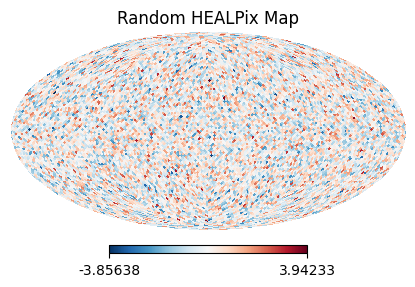

In [12]:
# Create a simple HEALPix map
nside = 32
npix = hp.nside2npix(nside)
single_map = np.random.randn(npix)

hp_single = HealpyMapSet(single_map)
fig, axes, _ = hp_single.plot(
    mollview_kwargs={'title': 'Random HEALPix Map', 'cmap': 'RdBu_r'}
)
plt.show()

### Example 3b: Batch of HEALPix Maps

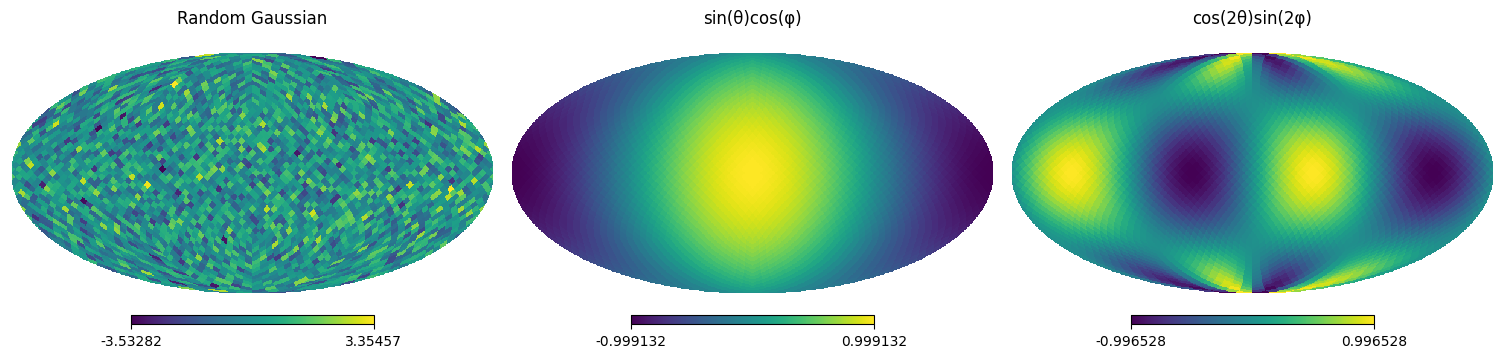

In [13]:
# Create multiple maps with different patterns
nside = 16
npix = hp.nside2npix(nside)

# Map 1: Random Gaussian
map1 = np.random.randn(npix)

# Map 2: Smooth gradient based on position
theta, phi = hp.pix2ang(nside, np.arange(npix))
map2 = np.sin(theta) * np.cos(phi)

# Map 3: Another pattern
map3 = np.cos(2*theta) * np.sin(2*phi)

batch_maps = np.array([map1, map2, map3])
hp_batch = HealpyMapSet(batch_maps)

fig, axes, _ = hp_batch.plot(
    ncols=3,
    figsize=(15, 4),
    mollview_kwargs={'cmap': 'viridis'}
)

# Can still customize axes
titles = ['Random Gaussian', 'sin(θ)cos(φ)', 'cos(2θ)sin(2φ)']
for ax, title in zip(axes, titles):
    ax.set_title(title, pad=20)

plt.show()

## 4. Composing Multiple Plot Types

The real power: mixing different plot types in a custom layout!

### Example 4a: Images + Spectra in Custom Layout

/tmp/ipykernel_109870/777201366.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


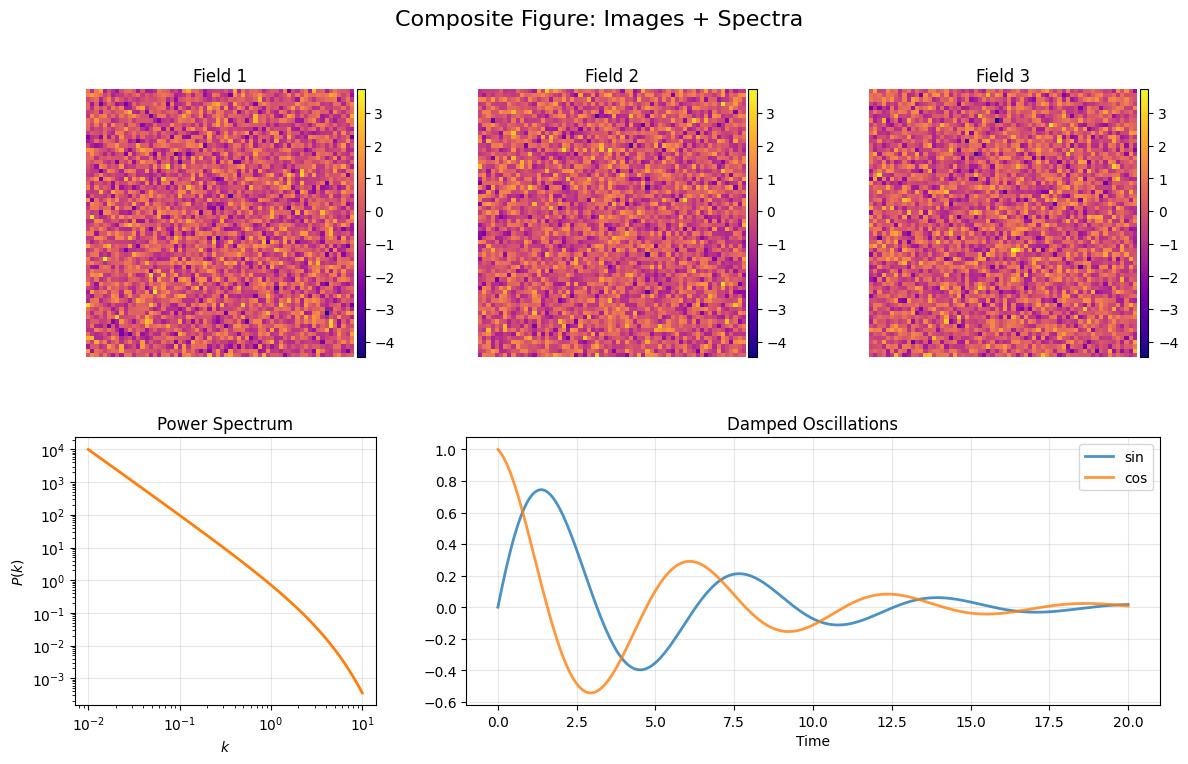

In [14]:
# Create a custom layout with GridSpec
fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Top row: 3 images
ax_imgs = [fig.add_subplot(gs[0, i]) for i in range(3)]
imgs_3 = ImageSet(np.random.randn(3, 64, 64))
_, axes_img, _ = imgs_3.plot(axes=ax_imgs, cmap='plasma')

for i, ax in enumerate(axes_img):
    ax.set_title(f'Field {i+1}')
    ax.axis('off')

# Bottom left: power spectrum
ax_power = fig.add_subplot(gs[1, 0])
k = np.logspace(-2, 1, 50)
P = k**(-2) * np.exp(-k/3)
power = SpectrumSet(k, P)
_, axes_power, _ = power.plot(axes=ax_power, color='C1', linewidth=2)
axes_power[0].set_xscale('log')
axes_power[0].set_yscale('log')
axes_power[0].set_title('Power Spectrum')
axes_power[0].set_xlabel(r'$k$')
axes_power[0].set_ylabel(r'$P(k)$')
axes_power[0].grid(True, alpha=0.3)

# Bottom middle/right: multiple spectra overlaid
ax_multi = fig.add_subplot(gs[1, 1:])
x_spec = np.linspace(0, 20, 300)
y_spec = np.array([
    np.exp(-x_spec/5) * np.sin(x_spec),
    np.exp(-x_spec/5) * np.cos(x_spec),
])
specs_damped = SpectrumSet(x_spec, y_spec)
_, axes_multi, lines = specs_damped.plot(
    axes=ax_multi, 
    one_panel=True, 
    alpha=0.8, 
    linewidth=2
)
axes_multi[0].set_title('Damped Oscillations')
axes_multi[0].set_xlabel('Time')
axes_multi[0].legend(lines, ['sin', 'cos'])
axes_multi[0].grid(True, alpha=0.3)

plt.suptitle('Composite Figure: Images + Spectra', fontsize=16, y=0.98)
plt.show()

### Example 4b: All Three Types Together

/tmp/ipykernel_109870/777201366.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


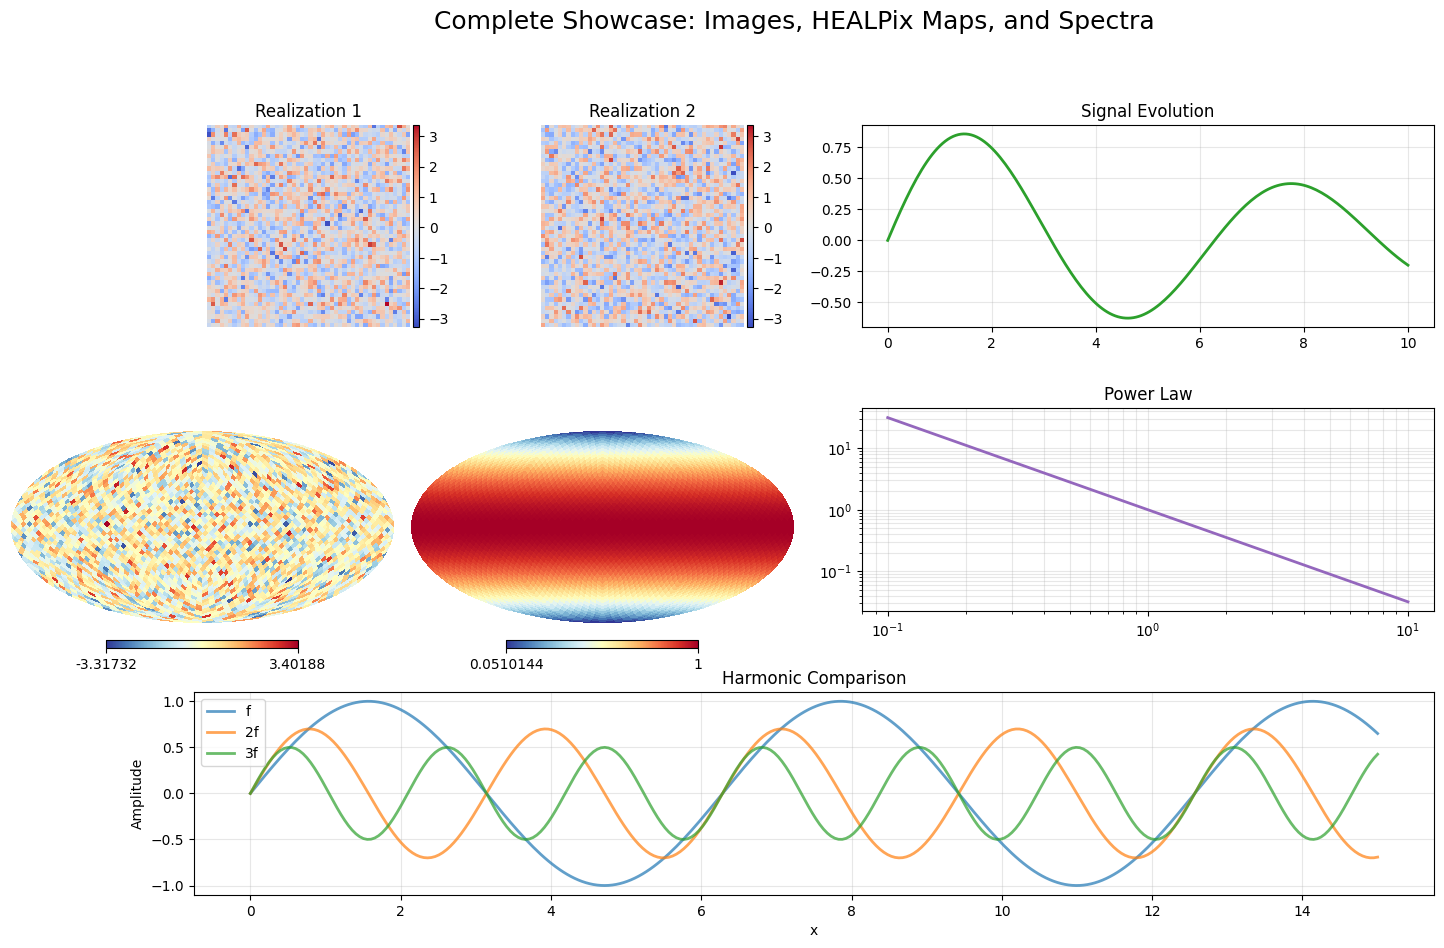

In [15]:
# Create a complex layout mixing all three types
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 4, figure=fig, hspace=0.4, wspace=0.4)

# Top left: 2 images
ax_img1 = fig.add_subplot(gs[0, 0])
ax_img2 = fig.add_subplot(gs[0, 1])
imgs_2 = ImageSet(np.random.randn(2, 48, 48))
_, axes_imgs, _ = imgs_2.plot(axes=[ax_img1, ax_img2], cmap='coolwarm')
axes_imgs[0].set_title('Realization 1')
axes_imgs[1].set_title('Realization 2')
for ax in axes_imgs:
    ax.axis('off')

# Top right: spectrum panel
ax_spec1 = fig.add_subplot(gs[0, 2:])
x1 = np.linspace(0, 10, 200)
y1 = np.sin(x1) * np.exp(-x1/10)
spec1 = SpectrumSet(x1, y1)
_, axes_s1, _ = spec1.plot(axes=ax_spec1, color='C2', linewidth=2)
axes_s1[0].set_title('Signal Evolution')
axes_s1[0].grid(True, alpha=0.3)

# Middle: HEALPix maps using custom subplot positions
# We need to use healpy's subplot syntax
nside_small = 16
npix_small = hp.nside2npix(nside_small)
hp_map1 = np.random.randn(npix_small)
hp_map2 = np.sin(hp.pix2ang(nside_small, np.arange(npix_small))[0])

hp_maps = HealpyMapSet(np.array([hp_map1, hp_map2]))
# Specify explicit subplot positions for healpy
_, hp_axes, _ = hp_maps.plot(
    fig=fig,
    subplots=[(3, 4, 5), (3, 4, 6)],  # middle row, first two cols
    mollview_kwargs={'cmap': 'RdYlBu_r', 'title': ''}
)

# Middle right: another spectrum
ax_spec2 = fig.add_subplot(gs[1, 2:])
k2 = np.logspace(-1, 1, 100)
P2 = k2**(-1.5)
spec2 = SpectrumSet(k2, P2)
_, axes_s2, _ = spec2.plot(axes=ax_spec2, color='C4', linewidth=2)
axes_s2[0].set_xscale('log')
axes_s2[0].set_yscale('log')
axes_s2[0].set_title('Power Law')
axes_s2[0].grid(True, alpha=0.3, which='both')

# Bottom: multiple spectra comparison
ax_compare = fig.add_subplot(gs[2, :])
x_comp = np.linspace(0, 15, 300)
y_comp = np.array([
    np.sin(x_comp),
    np.sin(2*x_comp) * 0.7,
    np.sin(3*x_comp) * 0.5,
])
spec_comp = SpectrumSet(x_comp, y_comp)
_, axes_comp, lines_comp = spec_comp.plot(
    axes=ax_compare,
    one_panel=True,
    alpha=0.7,
    linewidth=2
)
axes_comp[0].set_title('Harmonic Comparison')
axes_comp[0].set_xlabel('x')
axes_comp[0].set_ylabel('Amplitude')
axes_comp[0].legend(lines_comp, ['f', '2f', '3f'])
axes_comp[0].grid(True, alpha=0.3)

plt.suptitle(
    'Complete Showcase: Images, HEALPix Maps, and Spectra',
    fontsize=18,
    y=0.995
)
plt.show()

## Key Takeaways

1. **Consistency**: All plot objects follow the same pattern:
   - Accept optional `axes` parameter
   - Return `(fig, axes, artists)` tuple
   - Handle both single and batch data

2. **Flexibility**: Users can:
   - Get automatic layouts (just call `.plot()`)
   - Provide their own figure/axes for custom layouts
   - Continue customizing after the plot call

3. **Composability**: Mix different plot types in complex layouts by:
   - Creating a figure with GridSpec or subplots
   - Passing specific axes to each `.plot()` call
   - Further customizing the returned axes

4. **Return values enable further customization**:
   - Add colorbars, legends, titles
   - Adjust scales (log, linear)
   - Add annotations, extra data
   - Save figures with custom settings